<a href="https://colab.research.google.com/github/SurajSingh002/ML-Classification-Clustering-Fraud-Detection-Customer-Segmentation/blob/main/Untitled5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("creditcard.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31780 entries, 0 to 31779
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    31780 non-null  int64  
 1   V1      31780 non-null  float64
 2   V2      31780 non-null  float64
 3   V3      31780 non-null  float64
 4   V4      31780 non-null  float64
 5   V5      31780 non-null  float64
 6   V6      31780 non-null  float64
 7   V7      31779 non-null  float64
 8   V8      31779 non-null  float64
 9   V9      31779 non-null  float64
 10  V10     31779 non-null  float64
 11  V11     31779 non-null  float64
 12  V12     31779 non-null  float64
 13  V13     31779 non-null  float64
 14  V14     31779 non-null  float64
 15  V15     31779 non-null  float64
 16  V16     31779 non-null  float64
 17  V17     31779 non-null  float64
 18  V18     31779 non-null  float64
 19  V19     31779 non-null  float64
 20  V20     31779 non-null  float64
 21  V21     31779 non-null  float64
 22

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,31780.000000,31780.000000,31780.000000,31780.000000,31780.000000,31780.000000,31780.000000,31779.000000,31779.000000,31779.000000,...,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000
mean,22329.432410,-0.212640,0.104667,0.721370,0.211236,-0.209710,0.088247,-0.120162,0.031883,0.314021,...,-0.033146,-0.119157,-0.040436,0.008409,0.134365,0.022637,0.012911,0.003384,81.115001,0.003210
std,12184.540274,1.854714,1.547456,1.589832,1.420692,1.408421,1.314428,1.283076,1.264390,1.250651,...,0.778376,0.640252,0.539220,0.591869,0.435709,0.508922,0.390404,0.300394,223.154481,0.056564
min,0.000000,-30.552380,-40.978852,-31.103685,-5.172595,-42.147898,-23.496714,-26.548144,-41.484823,-7.175097,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.338556,-8.567638,-9.617915,0.000000,0.000000
25%,10971.000000,-0.956800,-0.467657,0.257092,-0.702958,-0.807339,-0.651105,-0.597343,-0.159243,-0.482553,...,-0.242905,-0.541636,-0.177032,-0.326931,-0.128724,-0.333026,-0.063132,-0.007594,6.790000,0.000000
50%,27331.000000,-0.246371,0.135141,0.842625,0.198585,-0.243626,-0.167815,-0.071105,0.038210,0.196750,...,-0.087460,-0.094216,-0.050669,0.062628,0.173028,-0.059277,0.008684,0.020795,20.000000,0.000000
75%,32942.000000,1.164230,0.776101,1.468823,1.095675,0.308333,0.474682,0.441280,0.298470,1.063590,...,0.087763,0.289984,0.075411,0.398097,0.417497,0.301347,0.089173,0.076435,73.705000,0.000000
max,36513.000000,1.960497,16.713389,4.101716,13.143668,34.099309,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,13.876221,4.014444,5.525093,3.517346,11.135740,5.678671,7879.420000,1.000000


In [ ]:
df.shape

(31780, 31)

In [ ]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        1
V8        1
V9        1
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [ ]:
print(df['Class'].value_counts())

Class
0.0    31677
1.0      102
Name: count, dtype: int64


In [ ]:
df = df.dropna(subset=['Class'])

In [ ]:
print(df['Class'].isnull().sum())

0


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
sm = SMOTE(k_neighbors=1, random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Class
0.0    25341
1.0       82
Name: count, dtype: int64


In [ ]:

print("\nAfter SMOTE:")
print(y_train_res.value_counts())


After SMOTE:
Class
0.0    25341
1.0    25341
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()

X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

In [ ]:
print("logistic")
print("randomForest")
print("XGBoost")

logistic
randomForest
XGBoost


In [ ]:
results = {}

for name, model in models.items():
    print(f"\n{name}")

    if name == "Logistic":
        model.fit(X_train_res_scaled, y_train_res)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    results[name] = model


Logistic
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      6336
         1.0       0.28      0.95      0.43        20

    accuracy                           0.99      6356
   macro avg       0.64      0.97      0.71      6356
weighted avg       1.00      0.99      0.99      6356

ROC-AUC: 0.9857796717171717

RandomForest
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6336
         1.0       0.85      0.85      0.85        20

    accuracy                           1.00      6356
   macro avg       0.92      0.92      0.92      6356
weighted avg       1.00      1.00      1.00      6356

ROC-AUC: 0.9734256628787878

XGBoost
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6336
         1.0       0.94      0.85      0.89        20

    accuracy                           1.00      6356
   macro avg       0.97      0.92      

In [ ]:
best_model = results["XGBoost"]

y_prob = best_model.predict_proba(X_test)[:,1]

In [ ]:
threshold = 0.7
y_pred_custom = (y_prob > threshold).astype(int)

print("\n AFTER THRESHOLD TUNING")
print(classification_report(y_test, y_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))


 AFTER THRESHOLD TUNING
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6336
         1.0       0.94      0.85      0.89        20

    accuracy                           1.00      6356
   macro avg       0.97      0.92      0.95      6356
weighted avg       1.00      1.00      1.00      6356

Confusion Matrix:
 [[6335    1]
 [   3   17]]


In [ ]:
print("\n Pipeline Completed ")


 Pipeline Completed 


PART    B  


 CUSTOMER SEGMENTATION

In [ ]:
df = pd.read_csv("Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.shape

(200, 5)

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
print(X_scaled[:10])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]]


In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

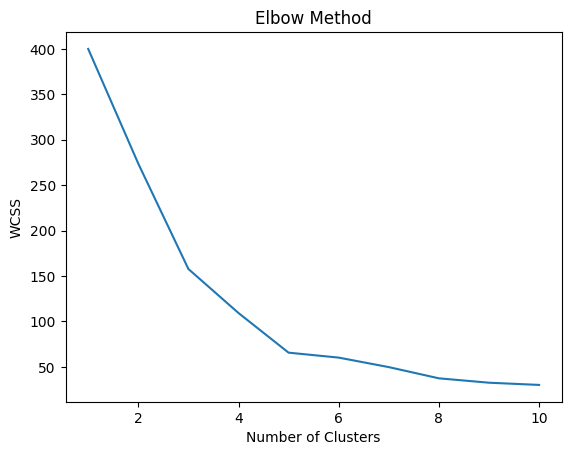

In [ ]:
plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
print(df['Cluster'].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


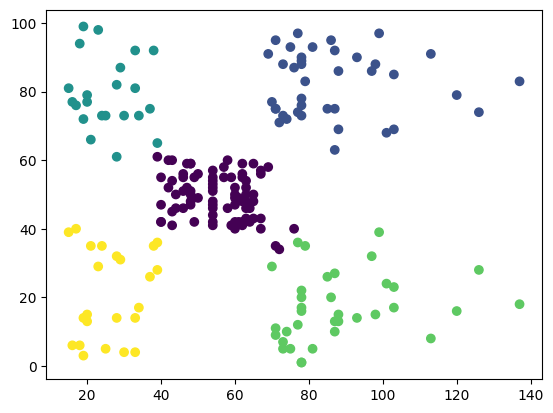

In [ ]:
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

In [ ]:
print(df.shape)
print(df.head())

(200, 6)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


In [ ]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


In [ ]:
print(df.groupby('Cluster')['Gender'].value_counts())

Cluster  Gender
0        Female    48
         Male      33
1        Female    21
         Male      18
2        Female    13
         Male       9
3        Male      19
         Female    16
4        Female    14
         Male       9
Name: count, dtype: int64


In [ ]:
print("Customer Segmentation Completed")

Customer Segmentation Completed
